In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r"C:\Users\MSI1\Downloads\Hotel_data\hotel_train.csv")
dfraw = df.copy()
dfraw

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,bookingID
0,"Crystal Cove, Barbados Barbados",0,8,2019,January,2,10,0,4,2,...,314.0,NaN,0,Transient,38.40,0,0,Check-Out,2019-01-14,1
1,"Greensboro Courtyard Greensboro, NC",1,524,2018,December,51,15,0,2,2,...,1.0,NaN,0,Transient,62.80,0,0,Canceled,2017-10-21,2
2,"The Westin Peachtree Plaza, Atlanta Atlanta, GA",1,175,2019,May,20,19,1,2,2,...,12.0,NaN,0,Transient,110.00,0,0,Canceled,2018-11-25,3
3,Courtyard by Marriott Aberdeen Airport Aberdee...,0,0,2018,October,43,17,1,0,1,...,NaN,200.0,0,Transient,45.00,0,0,Check-Out,2018-10-18,4
4,"W New York – Union Square New York, NY",1,33,2017,September,39,26,2,3,2,...,16.0,NaN,0,Transient,57.92,0,1,Canceled,2017-08-24,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
83288,"Crystal Cove, Barbados Barbados",0,4,2018,October,44,25,0,2,2,...,9.0,NaN,0,Transient,169.00,1,1,Check-Out,2018-10-27,83289
83289,"Berlin Marriott Hotel Berlin, Germany",0,30,2017,September,38,14,1,3,2,...,9.0,NaN,0,Transient,94.50,0,2,Check-Out,2017-09-18,83290
83290,"The Ritz-Carlton, Tokyo Tokyo, Japan",0,165,2019,June,25,21,4,10,2,...,NaN,NaN,0,Transient,123.50,0,1,Check-Out,2019-07-05,83291
83291,"Colony Club, Barbados Barbados",0,180,2018,July,32,31,2,4,2,...,9.0,NaN,0,Transient,122.25,0,1,Check-Out,2018-08-06,83292


## Data Structure Check
Tahap ini bertujuan untuk memahami struktur dasar dataset sebelum dilakukan proses pembersihan data (data cleaning). Analisis ini meliputi ukuran dataset, nama kolom, tipe data, statistik deskriptif, serta pemeriksaan konsistensi struktur data.

Melalui tahap ini dapat diketahui apakah terdapat ketidaksesuaian struktur data yang perlu diperbaiki sebelum masuk ke proses analisis lebih lanjut.

In [3]:
# Mengetahui jumlah baris dan kolom dari dataset

print("="*50)
print("Dataset Shape")
print("="*50)

print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]}")

Dataset Shape
Rows    : 83,293
Columns : 33


In [4]:
# Identifikasi seluruh nama kolom beserta urutannya untuk 
# memahami atribut yang tersedia pada dataset.

columns = pd.DataFrame({
    "Column Name": df.columns,
    "Data Type": df.dtypes.values
})

dtype_summary = (
    df.dtypes
      .value_counts()
      .rename_axis("Data Type")
      .reset_index(name="Total Columns")
)
display(columns)
display(dtype_summary)

,Column Name,Data Type
0,hotel,str
1,is_canceled,int64
2,lead_time,int64
3,arrival_date_year,int64
4,arrival_date_month,str
5,arrival_date_week_number,int64
6,arrival_date_day_of_month,int64
7,stays_in_weekend_nights,int64
8,stays_in_week_nights,int64
9,adults,int64


,Data Type,Total Columns
0,int64,17
1,str,12
2,float64,4


In [5]:
# Informasi dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 83293 entries, 0 to 83292
Data columns (total 33 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   hotel                           83293 non-null  str    
 1   is_canceled                     83293 non-null  int64  
 2   lead_time                       83293 non-null  int64  
 3   arrival_date_year               83293 non-null  int64  
 4   arrival_date_month              83293 non-null  str    
 5   arrival_date_week_number        83293 non-null  int64  
 6   arrival_date_day_of_month       83293 non-null  int64  
 7   stays_in_weekend_nights         83293 non-null  int64  
 8   stays_in_week_nights            83293 non-null  int64  
 9   adults                          83293 non-null  int64  
 10  children                        83290 non-null  float64
 11  babies                          83293 non-null  int64  
 12  meal                            83293 non-n

In [6]:
numeric_columns = df.select_dtypes(include=np.number).columns.tolist()
categorical_columns = df.select_dtypes(include='object').columns.tolist()

print("Numeric Columns:")
print(numeric_columns)

print("\nCategorical Columns:")
print(categorical_columns)

Numeric Columns:
['is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'agent', 'company', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'bookingID']

Categorical Columns:
['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type', 'reservation_status', 'reservation_status_date']


C:\Users\MSI1\AppData\Local\Temp\ipykernel_48604\3367274880.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include='object').columns.tolist()


Untuk dataset ini, reservation_status_date masih terbaca sebagai object, sehingga diubah menjadi datetime.

In [7]:
df['reservation_status_date'] = pd.to_datetime(
    df['reservation_status_date'],
    errors='coerce'
)

print(df['reservation_status_date'].dtype)

datetime64[us]


## Data Quality Check

In [8]:
# Pengecekan Missing Values

missing = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing Percentage': df.isnull().mean() * 100
})

missing = missing[missing['Missing Count'] > 0] \
    .sort_values('Missing Percentage', ascending=False)

missing

,Missing Count,Missing Percentage
company,78559,94.316449
agent,11404,13.691427
country,346,0.415401
children,3,0.003602


In [9]:
# Pengecekan Duplication
duplicate_count = df.duplicated().sum()

print(f"Jumlah duplicate rows: {duplicate_count}")

Jumlah duplicate rows: 0


In [10]:
print("Total booking ID :", df['bookingID'].count())
print("Unique booking ID:", df['bookingID'].nunique())

Total booking ID : 83293
Unique booking ID: 83293


In [11]:
# Nilai negatif
numeric_cols = df.select_dtypes(include=np.number).columns

(df[numeric_cols] < 0).sum().sort_values(ascending=False)

is_canceled                       0
previous_cancellations            0
total_of_special_requests         0
required_car_parking_spaces       0
adr                               0
days_in_waiting_list              0
company                           0
agent                             0
booking_changes                   0
previous_bookings_not_canceled    0
is_repeated_guest                 0
lead_time                         0
babies                            0
children                          0
adults                            0
stays_in_week_nights              0
stays_in_weekend_nights           0
arrival_date_day_of_month         0
arrival_date_week_number          0
arrival_date_year                 0
bookingID                         0
dtype: int64

#### Pengecekan Cancellation

In [12]:
target_count = df['is_canceled'].value_counts()
target_percentage = df['is_canceled'].value_counts(normalize=True) * 100


print(target_count)
print(target_percentage)

is_canceled
0    52516
1    30777
Name: count, dtype: int64
is_canceled
0    63.049716
1    36.950284
Name: proportion, dtype: float64


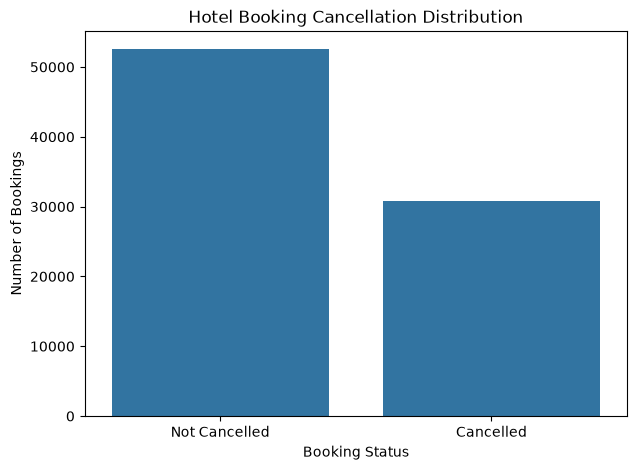

In [13]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x='is_canceled'
)

plt.title('Hotel Booking Cancellation Distribution')
plt.xlabel('Booking Status')
plt.ylabel('Number of Bookings')

plt.xticks(
    [0, 1],
    ['Not Cancelled', 'Cancelled']
)

plt.show()

In [14]:
df['total_guests'] = (
    df['adults'].fillna(0)
    + df['children'].fillna(0)
    + df['babies'].fillna(0)
)

zero_guest = df[df['total_guests'] == 0]


print("Booking tanpa guest:", len(zero_guest))


Booking tanpa guest: 127


In [15]:
zero_guest[['hotel',
            'is_canceled',
            'adults',
            'children',
            'babies',
            'adr',
            'market_segment',
            'customer_type']].head(20)

,hotel,is_canceled,adults,children,babies,adr,market_segment,customer_type
1377,Sheraton Grand Rio Hotel & Resort Rio de Janei...,0,0,0.0,0,97.40,Online TA,Transient
1726,Protea Hotel by Marriott Cape Town Sea Point C...,0,0,0.0,0,28.00,Direct,Transient
1991,Sheraton Mexico City Maria Isabel Hotel Mexico...,0,0,0.0,0,0.00,Online TA,Transient
2036,Baton Rouge Acadian Centre/LSU Area Courtyard ...,0,0,0.0,0,0.00,Online TA,Transient
2401,"Orlando Airport Courtyard Orlando, FL",0,0,0.0,0,0.00,Offline TA/TO,Transient
3724,"Grosvenor House, A JW Marriott Hotel London, U...",0,0,0.0,0,0.00,Offline TA/TO,Transient
3743,Protea Hotel by Marriott Cape Town Sea Point C...,0,0,0.0,0,0.00,Offline TA/TO,Transient
4770,"Crystal Cove, Barbados Barbados",0,0,0.0,0,0.00,Corporate,Group
5047,Renaissance New York Times Square Hotel New Yo...,0,0,0.0,0,32.85,Online TA,Transient
5567,Baton Rouge Acadian Centre/LSU Area Courtyard ...,0,0,0.0,0,89.20,Online TA,Transient


## Statistik Deskriptif

In [16]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
is_canceled,83293.0,0.369503,0.0,0.0,0.0,1.0,1.0,0.482673
lead_time,83293.0,103.91423,0.0,18.0,69.0,160.0,737.0,106.874124
arrival_date_year,83293.0,2018.156808,2017.0,2018.0,2018.0,2019.0,2019.0,0.706656
arrival_date_week_number,83293.0,27.164023,1.0,16.0,27.0,38.0,53.0,13.623752
arrival_date_day_of_month,83293.0,15.786116,1.0,8.0,16.0,23.0,31.0,8.775931
stays_in_weekend_nights,83293.0,0.93039,0.0,0.0,1.0,2.0,19.0,1.004196
stays_in_week_nights,83293.0,2.503812,0.0,1.0,2.0,3.0,50.0,1.924511
adults,83293.0,1.854466,0.0,2.0,2.0,2.0,55.0,0.606139
children,83290.0,0.103614,0.0,0.0,0.0,0.0,10.0,0.398821
babies,83293.0,0.008032,0.0,0.0,0.0,0.0,10.0,0.100641


In [17]:
numeric_summary = df[numeric_columns].describe().T

numeric_summary['missing'] = df[numeric_columns].isnull().sum()

numeric_summary

,count,mean,std,min,25%,50%,75%,max,missing
is_canceled,83293.0,0.369503,0.482673,0.0,0.00,0.0,1.0,1.0,0
lead_time,83293.0,103.914230,106.874124,0.0,18.00,69.0,160.0,737.0,0
arrival_date_year,83293.0,2018.156808,0.706656,2017.0,2018.00,2018.0,2019.0,2019.0,0
arrival_date_week_number,83293.0,27.164023,13.623752,1.0,16.00,27.0,38.0,53.0,0
arrival_date_day_of_month,83293.0,15.786116,8.775931,1.0,8.00,16.0,23.0,31.0,0
stays_in_weekend_nights,83293.0,0.930390,1.004196,0.0,0.00,1.0,2.0,19.0,0
stays_in_week_nights,83293.0,2.503812,1.924511,0.0,1.00,2.0,3.0,50.0,0
adults,83293.0,1.854466,0.606139,0.0,2.00,2.0,2.0,55.0,0
children,83290.0,0.103614,0.398821,0.0,0.00,0.0,0.0,10.0,3
babies,83293.0,0.008032,0.100641,0.0,0.00,0.0,0.0,10.0,0


In [18]:
df[categorical_columns].describe().T

,count,mean,min,25%,50%,75%,max
reservation_status_date,83293,2018-07-30 17:52:45.629765,2017-01-01 00:00:00,2018-02-01 00:00:00,2018-08-07 00:00:00,2019-02-07 00:00:00,2019-09-10 00:00:00


## Outliers

In [19]:
outlier_columns = [
    'lead_time',
    'stays_in_weekend_nights',
    'stays_in_week_nights',
    'adults',
    'children',
    'babies',
    'previous_cancellations',
    'previous_bookings_not_canceled',
    'booking_changes',
    'days_in_waiting_list',
    'adr',
    'required_car_parking_spaces',
    'total_of_special_requests'
]

outlier_summary = []

for col in outlier_columns:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    count = ((df[col] < lower) | (df[col] > upper)).sum()

    outlier_summary.append({
        'Column': col,
        'Q1': Q1,
        'Q3': Q3,
        'Lower Bound': lower,
        'Upper Bound': upper,
        'Outlier Count': count,
        'Outlier %': count / len(df) * 100
    })

outlier_df = pd.DataFrame(outlier_summary)

outlier_df.sort_values(
    'Outlier %',
    ascending=False
)

,Column,Q1,Q3,Lower Bound,Upper Bound,Outlier Count,Outlier %
3,adults,2.00,2.0,2.000,2.000,20920,25.116156
8,booking_changes,0.00,0.0,0.000,0.000,12703,15.250981
4,children,0.00,0.0,0.000,0.000,5961,7.156664
11,required_car_parking_spaces,0.00,0.0,0.000,0.000,5109,6.133769
6,previous_cancellations,0.00,0.0,0.000,0.000,4397,5.278955
10,adr,69.53,126.0,-15.175,210.705,2672,3.207953
9,days_in_waiting_list,0.00,0.0,0.000,0.000,2594,3.114307
7,previous_bookings_not_canceled,0.00,0.0,0.000,0.000,2532,3.039871
2,stays_in_week_nights,1.00,3.0,-2.000,6.000,2355,2.827368
0,lead_time,18.00,160.0,-195.000,373.000,2112,2.535627


## Cleaning

In [20]:
# Mengisi nilai yang hilang pada kolom dengan NA atau Unknown

df['children'] = df['children'].fillna(0)
df['country'] = df['country'].fillna('Unknown')
df['agent'] = df['agent'].fillna(0)
df['company'] = df['company'].fillna(0)

## Feature Engineering

In [21]:
df['total_stay_nights'] = (
    df['stays_in_weekend_nights']
    + df['stays_in_week_nights']
)

df['total_previous_bookings'] = (
    df['previous_cancellations']
    + df['previous_bookings_not_canceled']
)

df['cancellation_flag'] = df['is_canceled']

#### Datetime

In [22]:
month_map = {
    'January': 1,
    'February': 2,
    'March': 3,
    'April': 4,
    'May': 5,
    'June': 6,
    'July': 7,
    'August': 8,
    'September': 9,
    'October': 10,
    'November': 11,
    'December': 12
}

df['arrival_month_num'] = df['arrival_date_month'].map(month_map)

# Tandai tanggal yang tidak valid
df['arrival_date_invalid'] = False

invalid_mask = (
    (df['arrival_date_year'] == 2018) &
    (df['arrival_date_month'] == 'February') &
    (df['arrival_date_day_of_month'] == 29)
)

df.loc[invalid_mask, 'arrival_date_invalid'] = True

# Buat arrival_date
df['arrival_date'] = pd.to_datetime(
    dict(
        year=df['arrival_date_year'],
        month=df['arrival_month_num'],
        day=df['arrival_date_day_of_month']
    ),
    errors='coerce'
)

print("Invalid arrival date:", df['arrival_date_invalid'].sum())
print("Missing arrival date:", df['arrival_date'].isna().sum())

Invalid arrival date: 65
Missing arrival date: 65


In [23]:
df[['arrival_date',
    'arrival_date_year',
    'arrival_date_month',
    'arrival_date_day_of_month']].head()

,arrival_date,arrival_date_year,arrival_date_month,arrival_date_day_of_month
0,2019-01-10,2019,January,10
1,2018-12-15,2018,December,15
2,2019-05-19,2019,May,19
3,2018-10-17,2018,October,17
4,2017-09-26,2017,September,26


In [24]:
# Cek baris dengan arrival_date yang kosong

invalid_arrival_date = df[
    df['arrival_date'].isna()
][[
    'arrival_date_year',
    'arrival_date_month',
    'arrival_month_num',
    'arrival_date_day_of_month'
]]

invalid_arrival_date

,arrival_date_year,arrival_date_month,arrival_month_num,arrival_date_day_of_month
1565,2018,February,2,29
3069,2018,February,2,29
3081,2018,February,2,29
3792,2018,February,2,29
4488,2018,February,2,29
...,...,...,...,...
77857,2018,February,2,29
78926,2018,February,2,29
79306,2018,February,2,29
81571,2018,February,2,29


In [25]:
print("Jumlah invalid arrival date:",
      len(invalid_arrival_date))

print("\nDistribusi bulan:")
print(invalid_arrival_date['arrival_date_month'].value_counts())

print("\nDistribusi day:")
print(invalid_arrival_date['arrival_date_day_of_month'].value_counts())

Jumlah invalid arrival date: 65

Distribusi bulan:
arrival_date_month
February    65
Name: count, dtype: int64

Distribusi day:
arrival_date_day_of_month
29    65
Name: count, dtype: int64


#### Lead Time Category

In [26]:
def categorize_lead_time(x):

    if pd.isna(x):
        return 'Unknown'
    elif x <= 7:
        return '0–7 days'
    elif x <= 30:
        return '8–30 days'
    elif x <= 60:
        return '31–60 days'
    elif x <= 90:
        return '61–90 days'
    elif x <= 120:
        return '91–120 days'
    elif x <= 180:
        return '121–180 days'
    elif x <= 270:
        return '181–270 days'
    elif x <= 373:
        return '271–373 days'
    else:
        return '>373 days'


df['lead_time_category'] = df['lead_time'].apply(
    categorize_lead_time
)

In [27]:
lead_time_order = [
    '0–7 days',
    '8–30 days',
    '31–60 days',
    '61–90 days',
    '91–120 days',
    '121–180 days',
    '181–270 days',
    '271–373 days',
    '>373 days',
    'Unknown'
]

df['lead_time_category'] = pd.Categorical(
    df['lead_time_category'],
    categories=lead_time_order,
    ordered=True
)

In [28]:
lead_time_analysis = (
    df.groupby('lead_time_category', observed=False)
      .agg(
          total_bookings=('bookingID', 'count'),
          cancellations=('is_canceled', 'sum')
      )
)

lead_time_analysis['cancellation_rate'] = (
    lead_time_analysis['cancellations']
    / lead_time_analysis['total_bookings']
    * 100
)

lead_time_analysis

,total_bookings,cancellations,cancellation_rate
lead_time_category,,,
0–7 days,13739,1338,9.738700
8–30 days,13205,3638,27.550170
31–60 days,11970,4316,36.056809
61–90 days,8731,3469,39.731989
91–120 days,7282,3241,44.507004
121–180 days,11216,5031,44.855563
181–270 days,9289,4517,48.627409
271–373 days,5749,3823,66.498521
>373 days,2112,1404,66.477273


## Explanatory Data Analysis (EDA) on Lead Time and Cancellation Rate

In [29]:
# Cancellation Overview
cancellation_summary = pd.DataFrame({
    'Status': ['Not Cancelled', 'Cancelled'],
    'Bookings': [
        (df['is_canceled'] == 0).sum(),
        (df['is_canceled'] == 1).sum()
    ]
})

cancellation_summary['Percentage'] = (
    cancellation_summary['Bookings']
    / cancellation_summary['Bookings'].sum()
    * 100
).round(2)

cancellation_summary['Percentage'] = cancellation_summary['Percentage'].map(lambda x: f"{x:.2f}%")

cancellation_summary

,Status,Bookings,Percentage
0,Not Cancelled,52516,63.05%
1,Cancelled,30777,36.95%


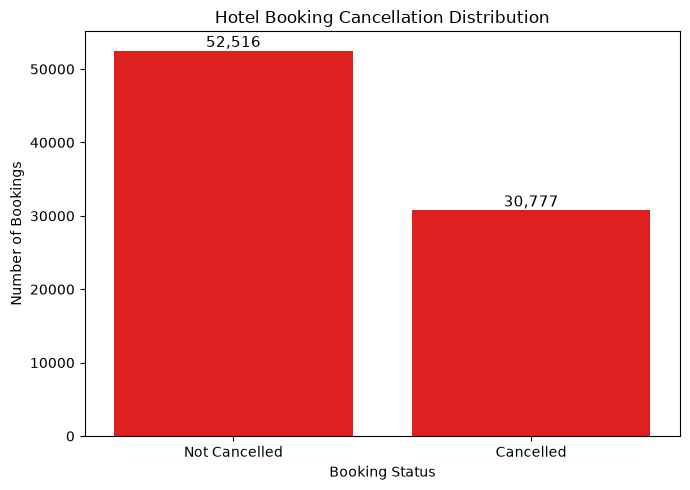

In [79]:
plt.figure(figsize=(7, 5))

ax = sns.countplot(
    data=df,
    x='is_canceled',
    color='red'
)

plt.title('Hotel Booking Cancellation Distribution')
plt.xlabel('Booking Status')
plt.ylabel('Number of Bookings')

plt.xticks(
    [0, 1],
    ['Not Cancelled', 'Cancelled']
)

for bar in ax.patches:
    ax.annotate(
        f'{int(bar.get_height()):,}',
        (bar.get_x() + bar.get_width() / 2, bar.get_height()),
        ha='center',
        va='bottom',
        fontsize=11
    )

plt.tight_layout()
plt.show()

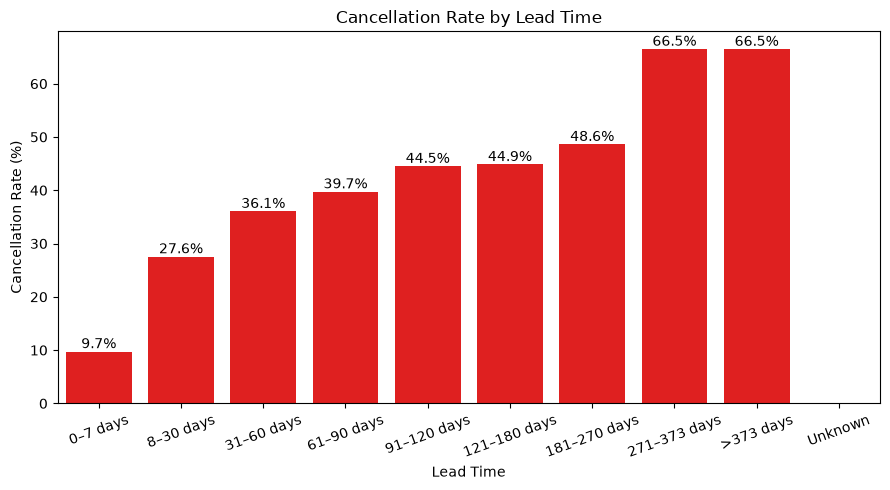

In [80]:
# Cancellation Rate by Lead Time

plt.figure(figsize=(9, 5))

ax = sns.barplot(
    data=lead_time_analysis.reset_index(),
    x='lead_time_category',
    y='cancellation_rate',
    color='red'
)

plt.title('Cancellation Rate by Lead Time')
plt.xlabel('Lead Time')
plt.ylabel('Cancellation Rate (%)')

plt.xticks(rotation=20)

for bar in ax.patches:
    height = bar.get_height()
    if not np.isnan(height):
        ax.annotate(
            f'{height:.1f}%',
            (bar.get_x() + bar.get_width() / 2, height),
            ha='center',
            va='bottom',
            fontsize=10
        )

plt.tight_layout()
plt.show()

In [32]:
# Deposit Type Analysis

deposit_analysis = (
    df.groupby('deposit_type')
      .agg(
          total_bookings=('bookingID', 'count'),
          cancellations=('is_canceled', 'sum')
      )
)

deposit_analysis['cancellation_rate'] = (
    deposit_analysis['cancellations']
    / deposit_analysis['total_bookings']
    * 100
)

deposit_analysis.sort_values(
    'cancellation_rate',
    ascending=False
)

,total_bookings,cancellations,cancellation_rate
deposit_type,,,
Non Refund,10204,10135,99.323795
No Deposit,72979,20618,28.251963
Refundable,110,24,21.818182


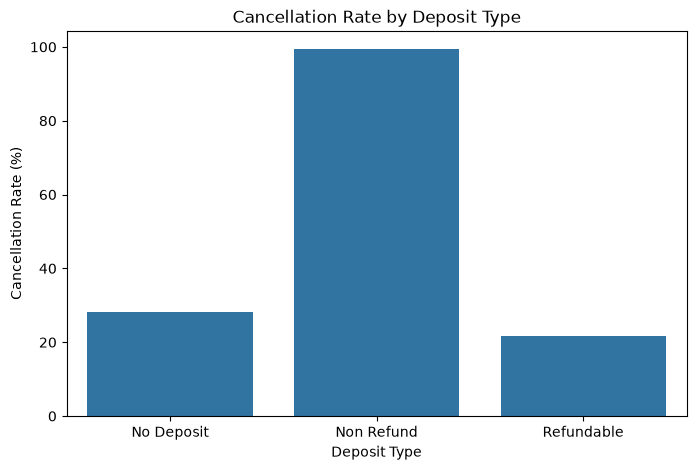

In [33]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=deposit_analysis.reset_index(),
    x='deposit_type',
    y='cancellation_rate'
)

plt.title('Cancellation Rate by Deposit Type')
plt.xlabel('Deposit Type')
plt.ylabel('Cancellation Rate (%)')

plt.show()

In [34]:
# Market Segment

segment_analysis = (
    df.groupby('market_segment')
      .agg(
          total_bookings=('bookingID', 'count'),
          cancellations=('is_canceled', 'sum')
      )
)

segment_analysis['cancellation_rate'] = (
    segment_analysis['cancellations']
    / segment_analysis['total_bookings']
    * 100
)

segment_analysis = segment_analysis.sort_values(
    'cancellation_rate',
    ascending=False
)

segment_analysis

,total_bookings,cancellations,cancellation_rate
market_segment,,,
Undefined,1,1,100.000000
Groups,13791,8365,60.655500
Online TA,39445,14452,36.638357
Offline TA/TO,16922,5804,34.298546
Aviation,162,40,24.691358
Corporate,3706,705,19.023206
Direct,8742,1346,15.396934
Complementary,524,64,12.213740


In [35]:
# Customer Type

customer_analysis = (
    df.groupby('customer_type')
      .agg(
          total_bookings=('bookingID', 'count'),
          cancellations=('is_canceled', 'sum')
      )
)

customer_analysis['cancellation_rate'] = (
    customer_analysis['cancellations']
    / customer_analysis['total_bookings']
    * 100
)

customer_analysis.sort_values(
    'cancellation_rate',
    ascending=False
)

,total_bookings,cancellations,cancellation_rate
customer_type,,,
Transient,62535,25499,40.775566
Contract,2793,854,30.576441
Transient-Party,17555,4379,24.944460
Group,410,45,10.975610


In [36]:
repeat_analysis = (
    df.groupby('is_repeated_guest')
      .agg(
          total_bookings=('bookingID', 'count'),
          cancellations=('is_canceled', 'sum')
      )
)

repeat_analysis['cancellation_rate'] = (
    repeat_analysis['cancellations']
    / repeat_analysis['total_bookings']
    * 100
)

repeat_analysis

,total_bookings,cancellations,cancellation_rate
is_repeated_guest,,,
0,80774,30516,37.779483
1,2519,261,10.361254


In [37]:
# Special Requests

df['special_requests_category'] = pd.cut(
    df['total_of_special_requests'],
    bins=[-1, 0, 1, 2, 3, 10],
    labels=['0', '1', '2', '3', '4+']
)

special_request_analysis = (
    df.groupby('special_requests_category')
      .agg(
          total_bookings=('bookingID', 'count'),
          cancellations=('is_canceled', 'sum')
      )
)

special_request_analysis['cancellation_rate'] = (
    special_request_analysis['cancellations']
    / special_request_analysis['total_bookings']
    * 100
)

special_request_analysis

,total_bookings,cancellations,cancellation_rate
special_requests_category,,,
0,49035,23357,47.633323
1,23200,5077,21.883621
2,9041,1999,22.110386
3,1743,319,18.301779
4+,274,25,9.124088


In [38]:
# Seasonality

month_order = [
    'January', 'February', 'March',
    'April', 'May', 'June',
    'July', 'August', 'September',
    'October', 'November', 'December'
]

monthly_analysis = (
    df.groupby('arrival_date_month')
      .agg(
          total_bookings=('bookingID', 'count'),
          cancellations=('is_canceled', 'sum')
      )
      .reindex(month_order)
)

monthly_analysis['cancellation_rate'] = (
    monthly_analysis['cancellations']
    / monthly_analysis['total_bookings']
    * 100
)

monthly_analysis

,total_bookings,cancellations,cancellation_rate
arrival_date_month,,,
January,4214,1298,30.802088
February,5560,1912,34.388489
March,6810,2197,32.261380
April,7787,3179,40.824451
May,8222,3264,39.698370
June,7666,3147,41.051396
July,8731,3243,37.143512
August,9643,3619,37.529814
September,7398,2833,38.294134


## Correlation Analysis

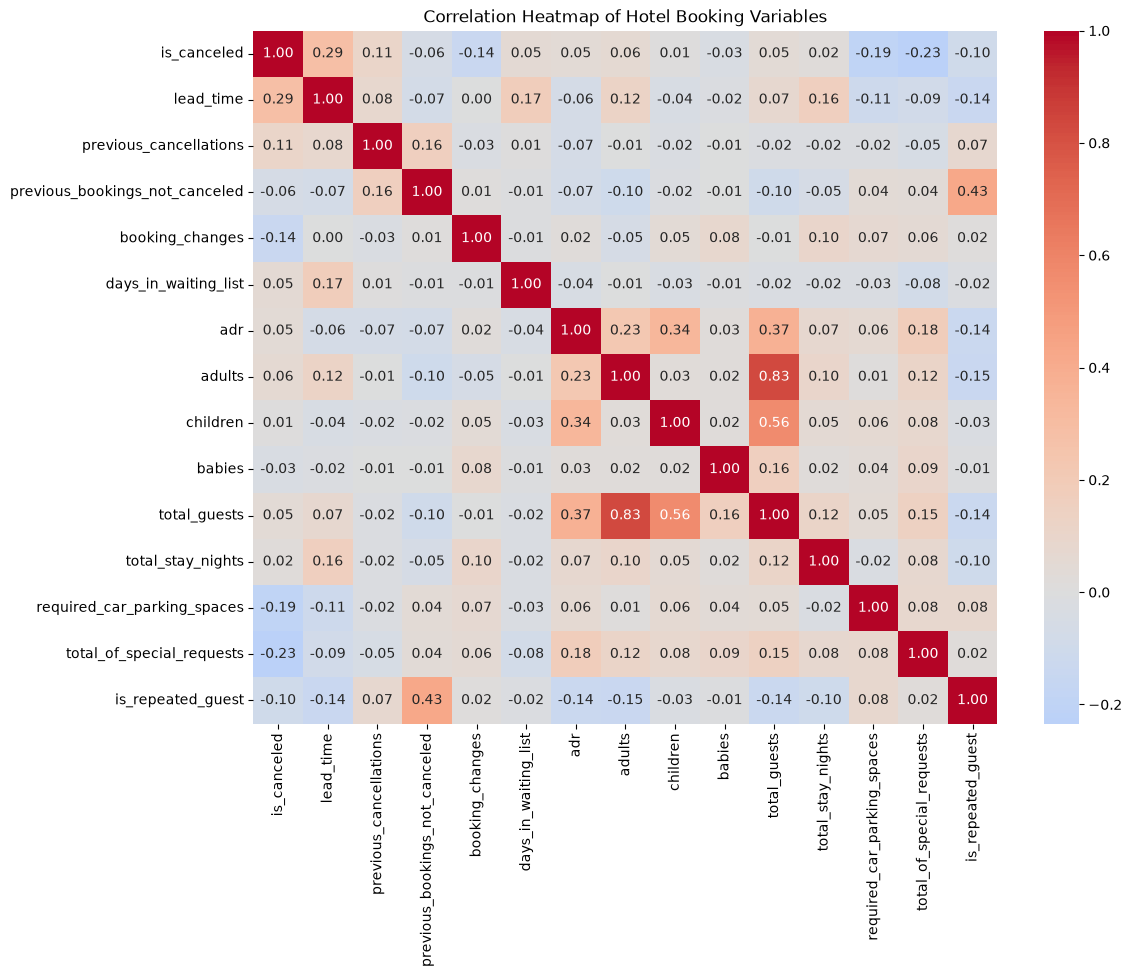

In [39]:
correlation_columns = [
    'is_canceled',
    'lead_time',
    'previous_cancellations',
    'previous_bookings_not_canceled',
    'booking_changes',
    'days_in_waiting_list',
    'adr',
    'adults',
    'children',
    'babies',
    'total_guests',
    'total_stay_nights',
    'required_car_parking_spaces',
    'total_of_special_requests',
    'is_repeated_guest'
]

corr_matrix = df[correlation_columns].corr()

plt.figure(figsize=(12,9))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)

plt.title('Correlation Heatmap of Hotel Booking Variables')

plt.show()

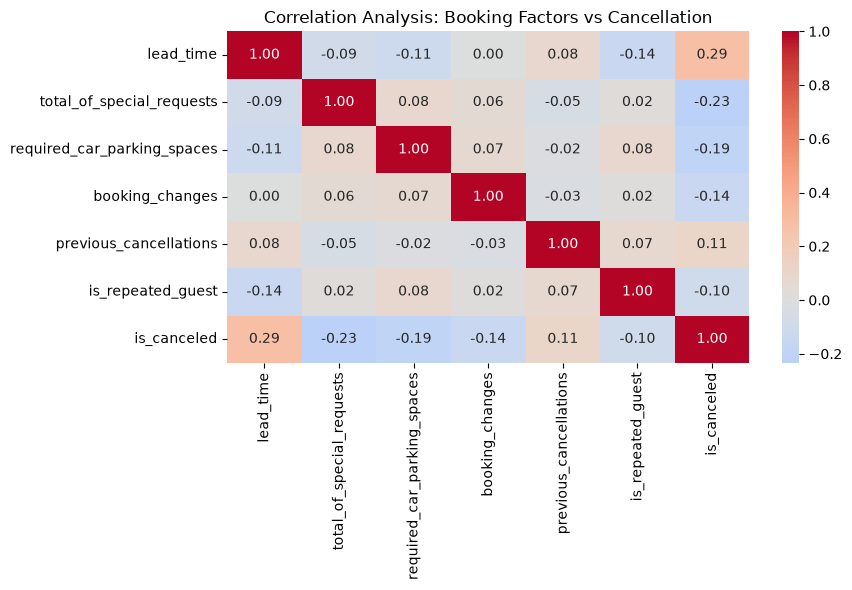

In [ ]:
corr_cols = [
    'lead_time',
    'total_of_special_requests',
    'required_car_parking_spaces',
    'booking_changes',
    'previous_cancellations',
    'is_repeated_guest',
    'is_canceled'
]

corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(9, 6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='Reds',
    fmt='.2f',
    center=0,
    vmin=-1,
    vmax=1
)

plt.title('Correlation Analysis: Booking Factors vs Cancellation')
plt.tight_layout()
plt.show()

In [77]:
# Correlation terhadap cancellation
corr_target = (
    df[corr_cols]
    .corr()['is_canceled']
    .drop('is_canceled')
    .sort_values(key=abs, ascending=False)
)

corr_target

lead_time                      0.290870
total_of_special_requests     -0.234052
required_car_parking_spaces   -0.193139
booking_changes               -0.143101
previous_cancellations         0.106460
is_repeated_guest             -0.097282
Name: is_canceled, dtype: float64

#### Deposit Type

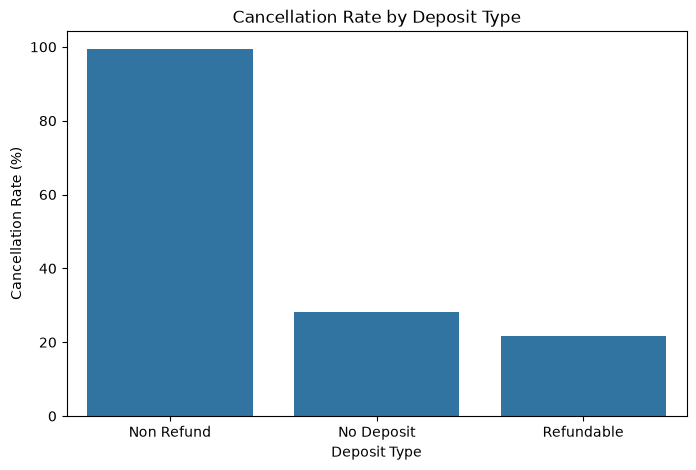

,total_bookings,cancellations,cancellation_rate
deposit_type,,,
Non Refund,10204,10135,99.323795
No Deposit,72979,20618,28.251963
Refundable,110,24,21.818182


In [41]:
deposit_analysis = (
    df.groupby('deposit_type')
      .agg(
          total_bookings=('bookingID', 'count'),
          cancellations=('is_canceled', 'sum')
      )
)

deposit_analysis['cancellation_rate'] = (
    deposit_analysis['cancellations']
    / deposit_analysis['total_bookings']
    * 100
)

deposit_analysis = deposit_analysis.sort_values(
    'cancellation_rate',
    ascending=False
)

plt.figure(figsize=(8, 5))

sns.barplot(
    data=deposit_analysis.reset_index(),
    x='deposit_type',
    y='cancellation_rate'
)

plt.title('Cancellation Rate by Deposit Type')
plt.xlabel('Deposit Type')
plt.ylabel('Cancellation Rate (%)')

plt.show()

deposit_analysis



#### Deposit Type × Lead Time

In [42]:
deposit_lead_analysis = (
    df.groupby(
        ['lead_time_category', 'deposit_type'],
        observed=False
    )
    .agg(
        total_bookings=('bookingID', 'count'),
        cancellations=('is_canceled', 'sum')
    )
)

deposit_lead_analysis['cancellation_rate'] = (
    deposit_lead_analysis['cancellations']
    / deposit_lead_analysis['total_bookings']
    * 100
)

deposit_lead_analysis.reset_index()

,lead_time_category,deposit_type,total_bookings,cancellations,cancellation_rate
0,0–7 days,No Deposit,13653,1270,9.301985
1,0–7 days,Non Refund,81,68,83.950617
2,0–7 days,Refundable,5,0,0.000000
3,8–30 days,No Deposit,12855,3316,25.795410
4,8–30 days,Non Refund,332,320,96.385542
5,8–30 days,Refundable,18,2,11.111111
6,31–60 days,No Deposit,11283,3633,32.198883
7,31–60 days,Non Refund,683,682,99.853587
8,31–60 days,Refundable,4,1,25.000000
9,61–90 days,No Deposit,7728,2470,31.961698


In [43]:
deposit_lead_pivot = deposit_lead_analysis[
    'cancellation_rate'
].unstack()

deposit_lead_pivot

deposit_type,No Deposit,Non Refund,Refundable
lead_time_category,,,
0–7 days,9.301985,83.950617,0.000000
8–30 days,25.795410,96.385542,11.111111
31–60 days,32.198883,99.853587,25.000000
61–90 days,31.961698,99.600400,100.000000
91–120 days,35.027340,99.906015,NaN
121–180 days,34.572531,98.298573,21.666667
181–270 days,37.938225,99.565757,25.000000
271–373 days,42.955019,100.000000,26.666667
>373 days,19.476082,100.000000,50.000000


In [44]:
deposit_volume_pivot = deposit_lead_analysis[
    'total_bookings'
].unstack()

deposit_volume_pivot

deposit_type,No Deposit,Non Refund,Refundable
lead_time_category,,,
0–7 days,13653,81,5
8–30 days,12855,332,18
31–60 days,11283,683,4
61–90 days,7728,1001,2
91–120 days,6218,1064,0
121–180 days,9334,1822,60
181–270 days,7673,1612,4
271–373 days,3357,2377,15
>373 days,878,1232,2


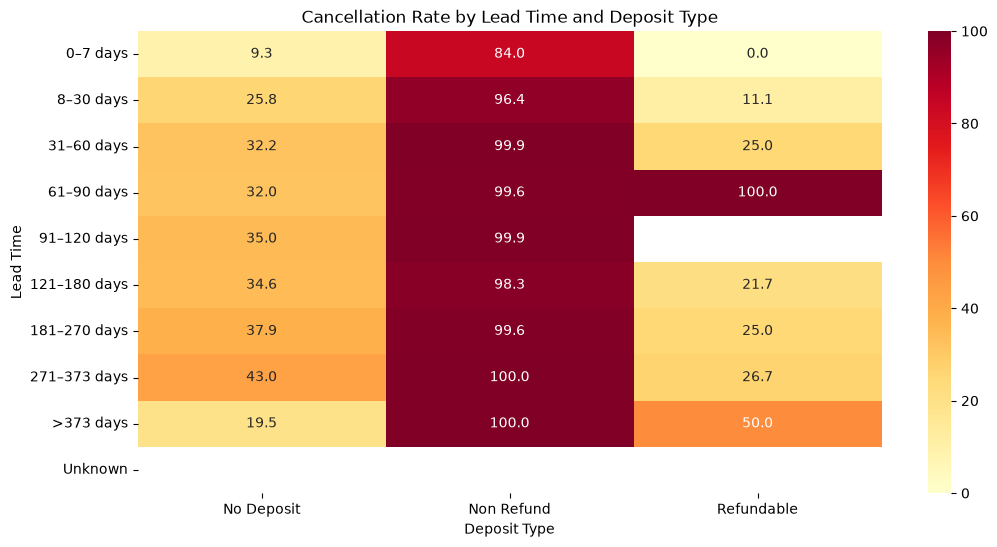

In [45]:
plt.figure(figsize=(12, 6))

sns.heatmap(
    deposit_lead_pivot,
    annot=True,
    fmt='.1f',
    cmap='YlOrRd'
)

plt.title('Cancellation Rate by Lead Time and Deposit Type')
plt.xlabel('Deposit Type')
plt.ylabel('Lead Time')

plt.show()

#### Market Segment

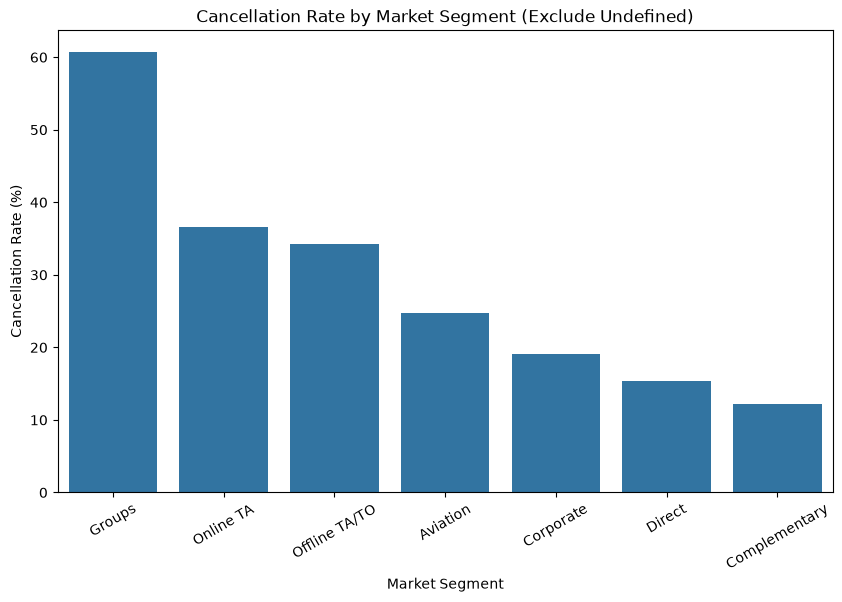

,total_bookings,cancellations,cancellation_rate,booking_share
market_segment,,,,
Groups,13791,8365,60.655500,16.557214
Online TA,39445,14452,36.638357,47.356921
Offline TA/TO,16922,5804,34.298546,20.316233
Aviation,162,40,24.691358,0.194494
Corporate,3706,705,19.023206,4.449353
Direct,8742,1346,15.396934,10.495480
Complementary,524,64,12.213740,0.629104


In [46]:
segment_analysis = (
    df[df['market_segment'] != 'Undefined']
      .groupby('market_segment')
      .agg(
          total_bookings=('bookingID', 'count'),
          cancellations=('is_canceled', 'sum')
      )
)

segment_analysis['cancellation_rate'] = (
    segment_analysis['cancellations']
    / segment_analysis['total_bookings']
    * 100
)

segment_analysis = segment_analysis.sort_values(
    'cancellation_rate',
    ascending=False
)

segment_analysis['booking_share'] = (
    segment_analysis['total_bookings']
    / df['bookingID'].count()
    * 100
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=segment_analysis.reset_index(),
    x='market_segment',
    y='cancellation_rate'
)

plt.title('Cancellation Rate by Market Segment (Exclude Undefined)')
plt.xlabel('Market Segment')
plt.ylabel('Cancellation Rate (%)')

plt.xticks(rotation=30)
plt.show()

segment_analysis

#### Market Segment × Lead Time

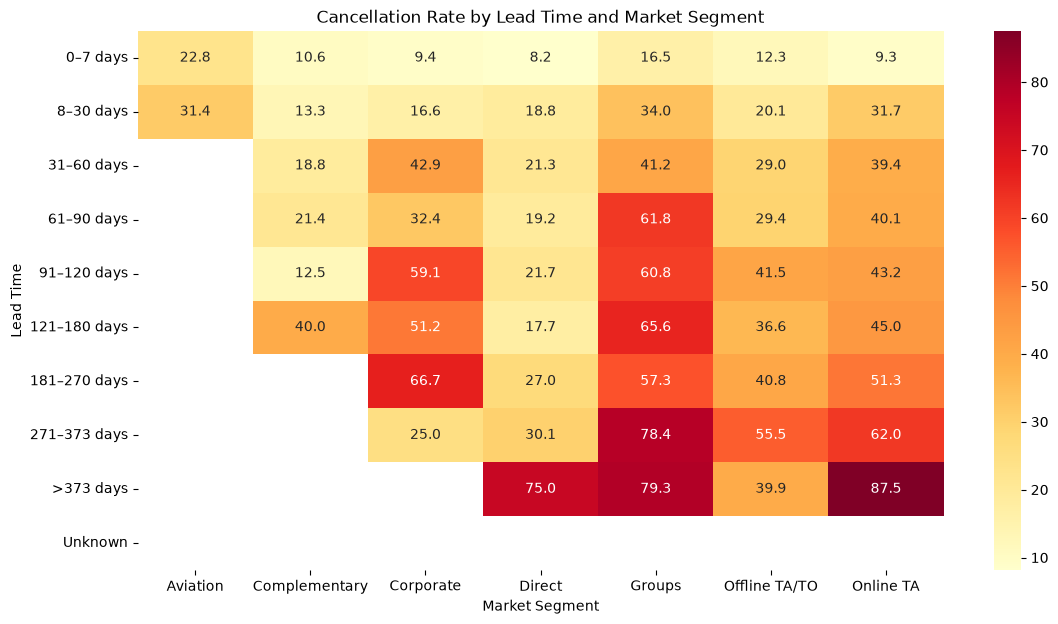

market_segment,Aviation,Complementary,Corporate,Direct,Groups,Offline TA/TO,Online TA
lead_time_category,,,,,,,
0–7 days,22.834646,10.555556,9.386282,8.163265,16.527197,12.296820,9.304333
8–30 days,31.428571,13.333333,16.594828,18.808777,34.025271,20.055710,31.705721
31–60 days,NaN,18.750000,42.892768,21.326531,41.211226,28.979592,39.404709
61–90 days,NaN,21.428571,32.352941,19.208211,61.783439,29.447480,40.054496
91–120 days,NaN,12.500000,59.090909,21.691974,60.802733,41.475147,43.157313
121–180 days,NaN,40.000000,51.162791,17.699115,65.588803,36.578171,44.984802
181–270 days,NaN,NaN,66.666667,26.956522,57.286432,40.836885,51.287766
271–373 days,NaN,NaN,25.000000,30.069930,78.381503,55.505108,61.962693
>373 days,NaN,NaN,NaN,75.000000,79.305457,39.912917,87.500000


In [47]:
segment_lead_analysis = (
    df[df['market_segment'] != 'Undefined']
      .groupby(
          ['lead_time_category', 'market_segment'],
          observed=False
      )
      .agg(
          total_bookings=('bookingID', 'count'),
          cancellations=('is_canceled', 'sum')
      )
)

segment_lead_analysis['cancellation_rate'] = (
    segment_lead_analysis['cancellations']
    / segment_lead_analysis['total_bookings']
    * 100
)

segment_lead_pivot = segment_lead_analysis[
    'cancellation_rate'
].unstack().drop(columns=['Undefined'], errors='ignore')

plt.figure(figsize=(13, 7))

sns.heatmap(
    segment_lead_pivot,
    annot=True,
    fmt='.1f',
    cmap='YlOrRd'
)

plt.title('Cancellation Rate by Lead Time and Market Segment')
plt.xlabel('Market Segment')
plt.ylabel('Lead Time')

plt.show()

segment_lead_pivot

#### Market Segment → Customer Type

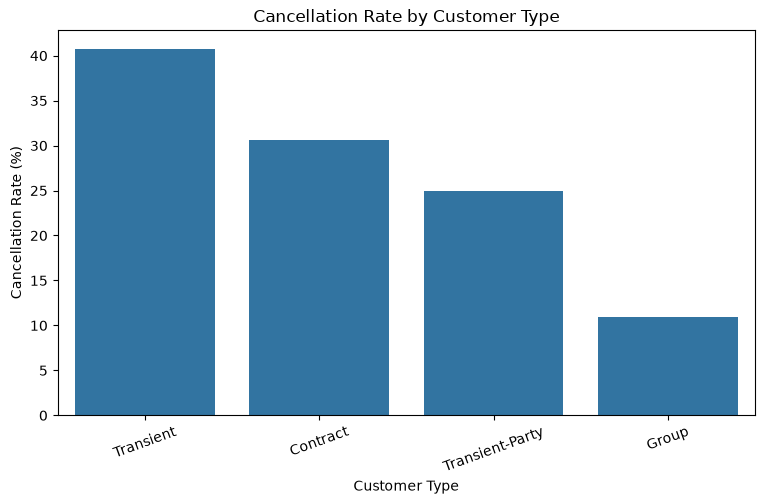

,total_bookings,cancellations,cancellation_rate
customer_type,,,
Transient,62535,25499,40.775566
Contract,2793,854,30.576441
Transient-Party,17555,4379,24.944460
Group,410,45,10.975610


In [48]:
customer_analysis = (
    df.groupby('customer_type')
      .agg(
          total_bookings=('bookingID', 'count'),
          cancellations=('is_canceled', 'sum')
      )
)

customer_analysis['cancellation_rate'] = (
    customer_analysis['cancellations']
    / customer_analysis['total_bookings']
    * 100
)

customer_analysis = customer_analysis.sort_values(
    'cancellation_rate',
    ascending=False
)


plt.figure(figsize=(9, 5))

sns.barplot(
    data=customer_analysis.reset_index(),
    x='customer_type',
    y='cancellation_rate'
)

plt.title('Cancellation Rate by Customer Type')
plt.xlabel('Customer Type')
plt.ylabel('Cancellation Rate (%)')

plt.xticks(rotation=20)

plt.show()
customer_analysis

#### Customer Type × Market Segment

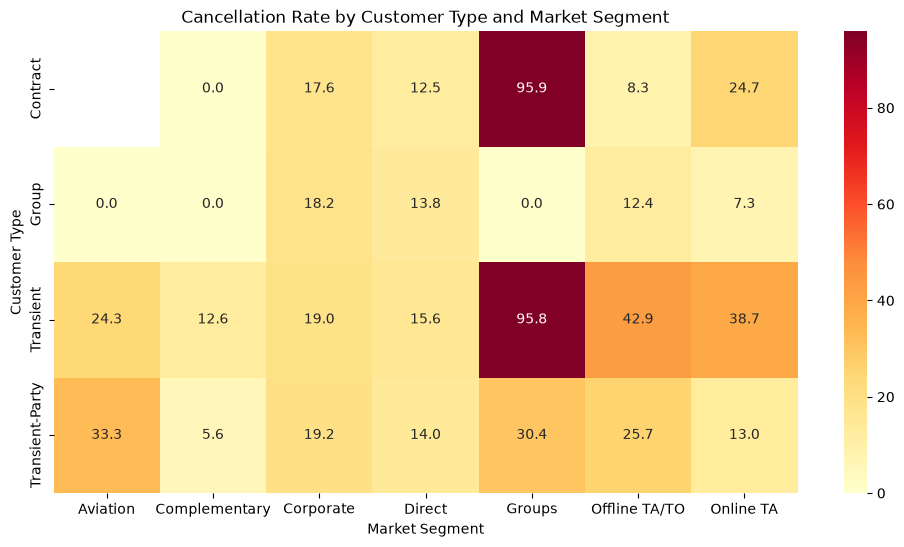

market_segment,Aviation,Complementary,Corporate,Direct,Groups,Offline TA/TO,Online TA
customer_type,,,,,,,
Contract,NaN,0.000000,17.647059,12.500000,95.938104,8.346840,24.704724
Group,0.000000,0.000000,18.181818,13.829787,0.000000,12.418301,7.317073
Transient,24.324324,12.574850,18.950793,15.553860,95.810627,42.937334,38.663844
Transient-Party,33.333333,5.555556,19.205298,14.028314,30.351827,25.710302,13.018242


In [49]:
customer_segment_analysis = (
    df[df['market_segment'] != 'Undefined']
      .groupby(['customer_type', 'market_segment'])
      .agg(
          total_bookings=('bookingID', 'count'),
          cancellations=('is_canceled', 'sum')
      )
)

customer_segment_analysis['cancellation_rate'] = (
    customer_segment_analysis['cancellations']
    / customer_segment_analysis['total_bookings']
    * 100
)

customer_segment_pivot = (
    customer_segment_analysis['cancellation_rate']
    .unstack()
    .drop(columns=['Undefined'], errors='ignore')
)

plt.figure(figsize=(12, 6))

sns.heatmap(
    customer_segment_pivot,
    annot=True,
    fmt='.1f',
    cmap='YlOrRd'
)

plt.title('Cancellation Rate by Customer Type and Market Segment')
plt.xlabel('Market Segment')
plt.ylabel('Customer Type')

plt.show()

customer_segment_pivot

#### Repeat Guest vs Cancellation

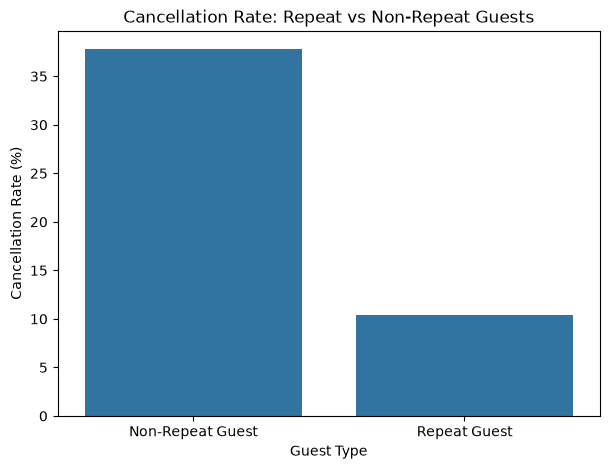

,total_bookings,cancellations,cancellation_rate
is_repeated_guest,,,
0,80774,30516,37.779483
1,2519,261,10.361254


In [50]:
repeat_analysis = (
    df.groupby('is_repeated_guest')
      .agg(
          total_bookings=('bookingID', 'count'),
          cancellations=('is_canceled', 'sum')
      )
)

repeat_analysis['cancellation_rate'] = (
    repeat_analysis['cancellations']
    / repeat_analysis['total_bookings']
    * 100
)

plt.figure(figsize=(7, 5))

sns.barplot(
    data=repeat_analysis.reset_index(),
    x='is_repeated_guest',
    y='cancellation_rate'
)

plt.title('Cancellation Rate: Repeat vs Non-Repeat Guests')
plt.xlabel('Guest Type')
plt.ylabel('Cancellation Rate (%)')

plt.xticks(
    [0, 1],
    ['Non-Repeat Guest', 'Repeat Guest']
)


plt.show()

repeat_analysis

In [51]:
repeat_analysis['booking_share'] = (
    repeat_analysis['total_bookings']
    / repeat_analysis['total_bookings'].sum()
    * 100
)

repeat_analysis

,total_bookings,cancellations,cancellation_rate,booking_share
is_repeated_guest,,,,
0,80774,30516,37.779483,96.975736
1,2519,261,10.361254,3.024264


#### Distribusi total_of_special_requests

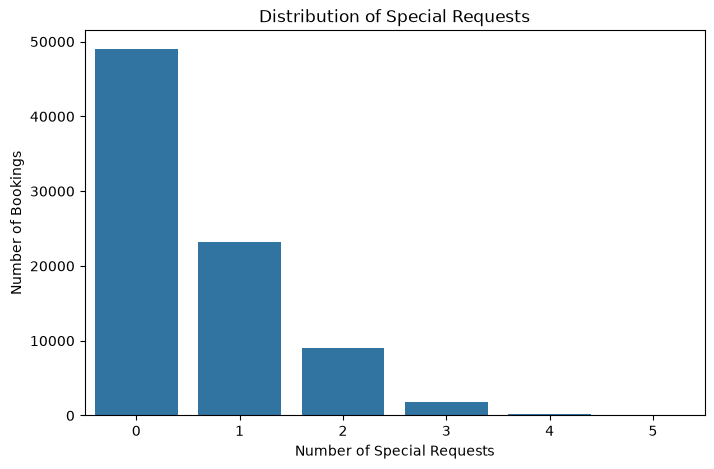

total_of_special_requests
0    49035
1    23200
2     9041
3     1743
4      242
5       32
Name: count, dtype: int64

In [52]:
special_request_distribution = (
    df['total_of_special_requests']
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x='total_of_special_requests'
)

plt.title('Distribution of Special Requests')
plt.xlabel('Number of Special Requests')
plt.ylabel('Number of Bookings')

plt.show()

special_request_distribution

#### Cancellation rate berdasarkan jumlah request

In [53]:
special_request_analysis = (
    df.groupby('total_of_special_requests')
      .agg(
          total_bookings=('bookingID', 'count'),
          cancellations=('is_canceled', 'sum')
      )
)

special_request_analysis['cancellation_rate'] = (
    special_request_analysis['cancellations']
    / special_request_analysis['total_bookings']
    * 100
)

special_request_analysis['booking_share'] = (
    special_request_analysis['total_bookings']
    / special_request_analysis['total_bookings'].sum()
    * 100
)

special_request_analysis

,total_bookings,cancellations,cancellation_rate,booking_share
total_of_special_requests,,,,
0,49035,23357,47.633323,58.870493
1,23200,5077,21.883621,27.853481
2,9041,1999,22.110386,10.854454
3,1743,319,18.301779,2.092613
4,242,23,9.504132,0.290541
5,32,2,6.250000,0.038419


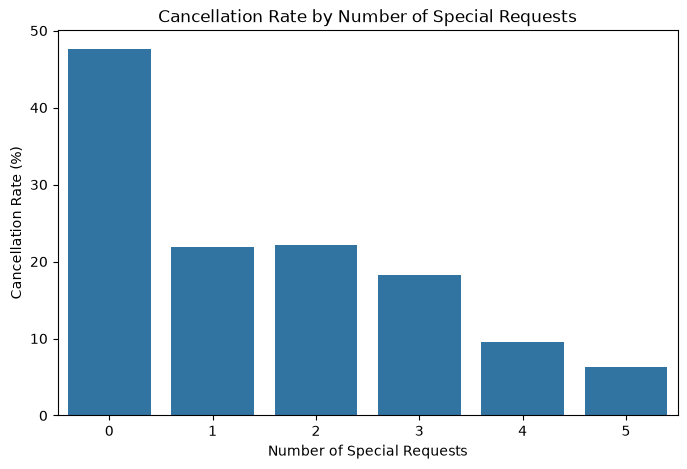

In [54]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=special_request_analysis.reset_index(),
    x='total_of_special_requests',
    y='cancellation_rate'
)

plt.title('Cancellation Rate by Number of Special Requests')
plt.xlabel('Number of Special Requests')
plt.ylabel('Cancellation Rate (%)')

plt.show()

#### Seasonality / Arrival Month

In [55]:
month_order = [
    'January',
    'February',
    'March',
    'April',
    'May',
    'June',
    'July',
    'August',
    'September',
    'October',
    'November',
    'December'
]

monthly_analysis = (
    df.groupby('arrival_date_month')
      .agg(
          total_bookings=('bookingID', 'count'),
          cancellations=('is_canceled', 'sum')
      )
)

monthly_analysis['cancellation_rate'] = (
    monthly_analysis['cancellations']
    / monthly_analysis['total_bookings']
    * 100
)

monthly_analysis['booking_share'] = (
    monthly_analysis['total_bookings']
    / monthly_analysis['total_bookings'].sum()
    * 100
)

monthly_analysis = monthly_analysis.reindex(month_order)

monthly_analysis

,total_bookings,cancellations,cancellation_rate,booking_share
arrival_date_month,,,,
January,4214,1298,30.802088,5.059249
February,5560,1912,34.388489,6.675231
March,6810,2197,32.261380,8.175957
April,7787,3179,40.824451,9.348925
May,8222,3264,39.698370,9.871178
June,7666,3147,41.051396,9.203655
July,8731,3243,37.143512,10.482273
August,9643,3619,37.529814,11.577203
September,7398,2833,38.294134,8.881899


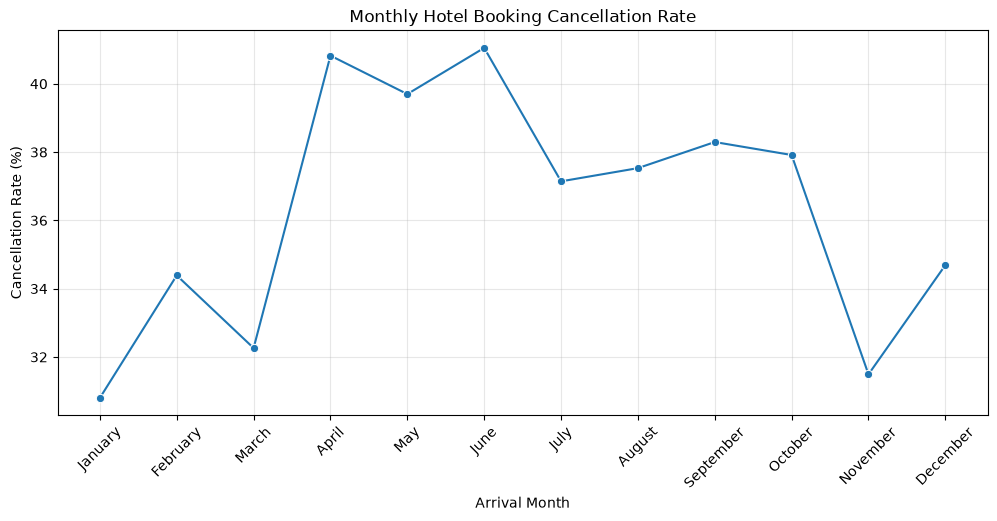

In [56]:
plt.figure(figsize=(12, 5))

sns.lineplot(
    data=monthly_analysis,
    x=monthly_analysis.index,
    y='cancellation_rate',
    marker='o'
)

plt.title('Monthly Hotel Booking Cancellation Rate')
plt.xlabel('Arrival Month')
plt.ylabel('Cancellation Rate (%)')

plt.xticks(rotation=45)
plt.grid(alpha=0.3)

plt.show()

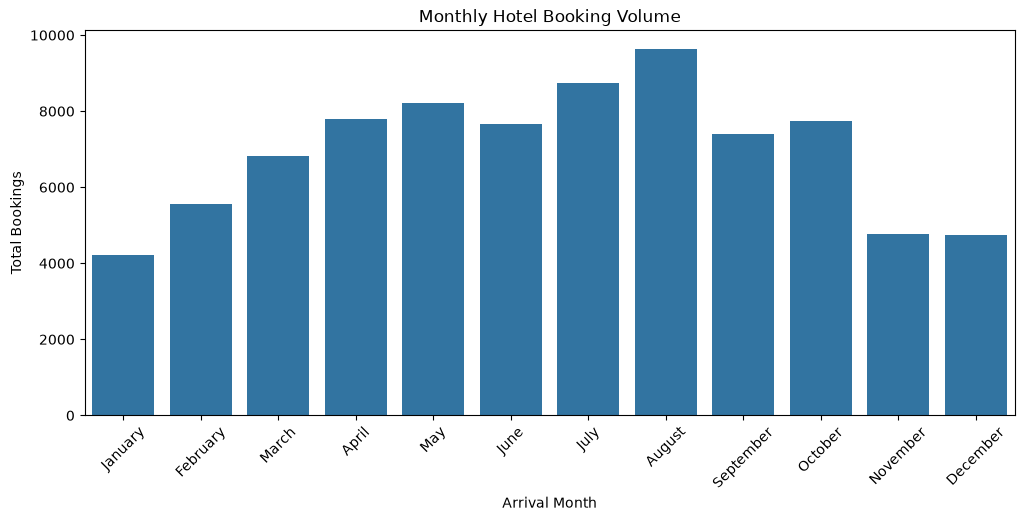

In [57]:
plt.figure(figsize=(12, 5))

sns.barplot(
    data=monthly_analysis,
    x=monthly_analysis.index,
    y='total_bookings'
)

plt.title('Monthly Hotel Booking Volume')
plt.xlabel('Arrival Month')
plt.ylabel('Total Bookings')

plt.xticks(rotation=45)

plt.show()

In [58]:
year_month_analysis = (
    df.groupby(
        ['arrival_date_year', 'arrival_date_month']
    )
    .agg(
        total_bookings=('bookingID', 'count'),
        cancellations=('is_canceled', 'sum')
    )
)

year_month_analysis['cancellation_rate'] = (
    year_month_analysis['cancellations']
    / year_month_analysis['total_bookings']
    * 100
)

year_month_analysis

total_bookings  cancellations  \
arrival_date_year arrival_date_month                                  
2017              August                        2699           1079   
                  December                      2040            667   
                  July                          1846            802   
                  November                      1632            341   
                  October                       3475           1207   
                  September                     3598           1443   
2018              April                         3840           1451   
                  August                        3514           1273   
                  December                      2702            978   
                  February                      2677            968   
                  January                       1591            394   
                  July                          3168           1040   
                  June                          3734           1463   
                  March                         3354           1027   
                  May                           3859           1356   
                  November                      3147           1164   
                  October                       4266           1728   
                  September                     3800           1390   
2019              April                         3947           1728   
                  August                        3430           1267   
                  February                      2883            944   
                  January                       2623            904   
                  July                          3717           1401   
                  June                          3932           1684   
                  March                         3456           1170   
                  May                           4363           1908   

                                      cancellation_rate  
arrival_date_year arrival_date_month                     
2017              August                      39.977770  
                  December                    32.696078  
                  July                        43.445287  
                  November                    20.894608  
                  October                     34.733813  
                  September                   40.105614  
2018              April                       37.786458  
                  August                      36.226522  
                  December                    36.195411  
                  February                    36.159880  
                  January                     24.764299  
                  July                        32.828283  
                  June                        39.180503  
                  March                       30.620155  
                  May                         35.138637  
                  November                    36.987607  
                  October                     40.506329  
                  September                   36.578947  
2019              April                       43.780086  
                  August                      36.938776  
                  February                    32.743670  
                  January                     34.464354  
                  July                        37.691687  
                  June                        42.828077  
                  March                       33.854167  
                  May                         43.731377

In [59]:
year_month_pivot = (
    year_month_analysis['cancellation_rate']
    .unstack()
    .reindex(columns=month_order)
)

year_month_pivot

arrival_date_month,January,February,March,April,May,June,July,August,September,October,November,December
arrival_date_year,,,,,,,,,,,,
2017,NaN,NaN,NaN,NaN,NaN,NaN,43.445287,39.977770,40.105614,34.733813,20.894608,32.696078
2018,24.764299,36.15988,30.620155,37.786458,35.138637,39.180503,32.828283,36.226522,36.578947,40.506329,36.987607,36.195411
2019,34.464354,32.74367,33.854167,43.780086,43.731377,42.828077,37.691687,36.938776,NaN,NaN,NaN,NaN


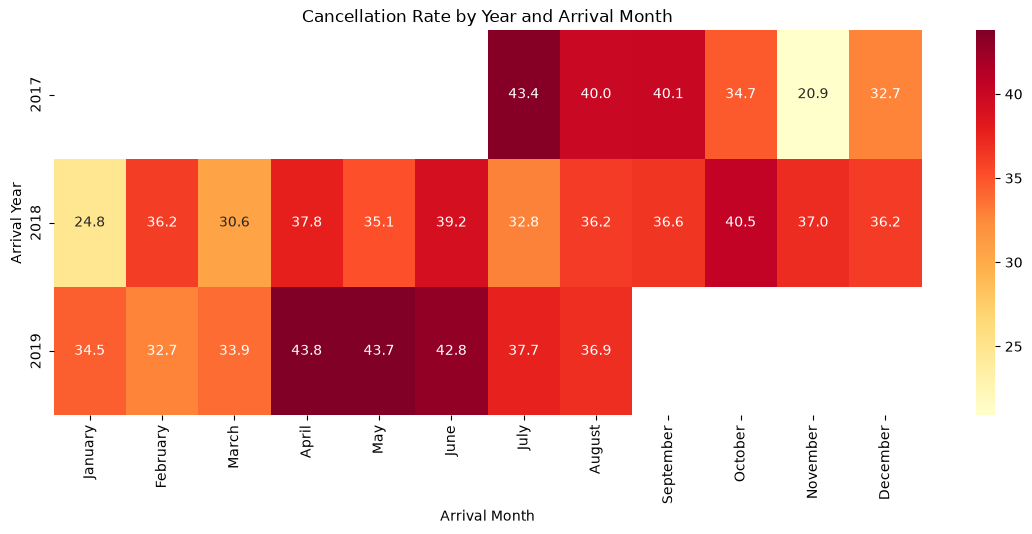

In [60]:
plt.figure(figsize=(14, 5))

sns.heatmap(
    year_month_pivot,
    annot=True,
    fmt='.1f',
    cmap='YlOrRd'
)

plt.title('Cancellation Rate by Year and Arrival Month')
plt.xlabel('Arrival Month')
plt.ylabel('Arrival Year')

plt.show()

## Multivariate Analysis

In [61]:
# Deposit Type

factor_deposit = (
    df.groupby('deposit_type')
      .agg(
          total_bookings=('bookingID', 'count'),
          cancellations=('is_canceled', 'sum')
      )
)

factor_deposit['cancellation_rate'] = (
    factor_deposit['cancellations']
    / factor_deposit['total_bookings']
    * 100
)

factor_deposit['booking_share'] = (
    factor_deposit['total_bookings']
    / len(df)
    * 100
)

factor_deposit

,total_bookings,cancellations,cancellation_rate,booking_share
deposit_type,,,,
No Deposit,72979,20618,28.251963,87.617207
Non Refund,10204,10135,99.323795,12.250729
Refundable,110,24,21.818182,0.132064


In [62]:
# Market Segment

factor_segment = (
    df.groupby('market_segment')
      .agg(
          total_bookings=('bookingID', 'count'),
          cancellations=('is_canceled', 'sum')
      )
)

factor_segment['cancellation_rate'] = (
    factor_segment['cancellations']
    / factor_segment['total_bookings']
    * 100
)

factor_segment['booking_share'] = (
    factor_segment['total_bookings']
    / len(df)
    * 100
)

factor_segment

,total_bookings,cancellations,cancellation_rate,booking_share
market_segment,,,,
Aviation,162,40,24.691358,0.194494
Complementary,524,64,12.213740,0.629104
Corporate,3706,705,19.023206,4.449353
Direct,8742,1346,15.396934,10.495480
Groups,13791,8365,60.655500,16.557214
Offline TA/TO,16922,5804,34.298546,20.316233
Online TA,39445,14452,36.638357,47.356921
Undefined,1,1,100.000000,0.001201


In [63]:
# Customer Type

factor_customer = (
    df.groupby('customer_type')
      .agg(
          total_bookings=('bookingID', 'count'),
          cancellations=('is_canceled', 'sum')
      )
)

factor_customer['cancellation_rate'] = (
    factor_customer['cancellations']
    / factor_customer['total_bookings']
    * 100
)

factor_customer['booking_share'] = (
    factor_customer['total_bookings']
    / len(df)
    * 100
)

factor_customer

,total_bookings,cancellations,cancellation_rate,booking_share
customer_type,,,,
Contract,2793,854,30.576441,3.353223
Group,410,45,10.975610,0.492238
Transient,62535,25499,40.775566,75.078338
Transient-Party,17555,4379,24.944460,21.076201


In [64]:
overall_cancel_rate = df['is_canceled'].mean() * 100

lead_time_analysis['risk_vs_overall'] = (
    lead_time_analysis['cancellation_rate']
    / overall_cancel_rate
)

lead_time_analysis

,total_bookings,cancellations,cancellation_rate,risk_vs_overall
lead_time_category,,,,
0–7 days,13739,1338,9.738700,0.263562
8–30 days,13205,3638,27.550170,0.745601
31–60 days,11970,4316,36.056809,0.975820
61–90 days,8731,3469,39.731989,1.075282
91–120 days,7282,3241,44.507004,1.204510
121–180 days,11216,5031,44.855563,1.213944
181–270 days,9289,4517,48.627409,1.316023
271–373 days,5749,3823,66.498521,1.799676
>373 days,2112,1404,66.477273,1.799100


In [65]:
risk_segment = (
    df.groupby(
        ['lead_time_category', 'deposit_type'],
        observed=False
    )
    .agg(
        total_bookings=('bookingID', 'count'),
        cancellations=('is_canceled', 'sum')
    )
)

risk_segment['cancellation_rate'] = (
    risk_segment['cancellations']
    / risk_segment['total_bookings']
    * 100
)

risk_segment['booking_share'] = (
    risk_segment['total_bookings']
    / len(df)
    * 100
)

risk_segment = risk_segment.reset_index()

risk_segment = risk_segment[
    risk_segment['total_bookings'] >= 100
]

risk_segment.sort_values(
    'cancellation_rate',
    ascending=False
).head(15)

,lead_time_category,deposit_type,total_bookings,cancellations,cancellation_rate,booking_share
25,>373 days,Non Refund,1232,1232,100.000000,1.479116
22,271–373 days,Non Refund,2377,2377,100.000000,2.853781
13,91–120 days,Non Refund,1064,1063,99.906015,1.277418
7,31–60 days,Non Refund,683,682,99.853587,0.819997
10,61–90 days,Non Refund,1001,997,99.600400,1.201782
19,181–270 days,Non Refund,1612,1605,99.565757,1.935337
16,121–180 days,Non Refund,1822,1791,98.298573,2.187459
4,8–30 days,Non Refund,332,320,96.385542,0.398593
21,271–373 days,No Deposit,3357,1442,42.955019,4.030351
18,181–270 days,No Deposit,7673,2911,37.938225,9.212059


In [66]:
high_risk = risk_segment[
    (risk_segment['cancellation_rate'] >= 50) &
    (risk_segment['total_bookings'] >= 100)
].sort_values(
    'cancellation_rate',
    ascending=False
)

high_risk

,lead_time_category,deposit_type,total_bookings,cancellations,cancellation_rate,booking_share
22,271–373 days,Non Refund,2377,2377,100.000000,2.853781
25,>373 days,Non Refund,1232,1232,100.000000,1.479116
13,91–120 days,Non Refund,1064,1063,99.906015,1.277418
7,31–60 days,Non Refund,683,682,99.853587,0.819997
10,61–90 days,Non Refund,1001,997,99.600400,1.201782
19,181–270 days,Non Refund,1612,1605,99.565757,1.935337
16,121–180 days,Non Refund,1822,1791,98.298573,2.187459
4,8–30 days,Non Refund,332,320,96.385542,0.398593


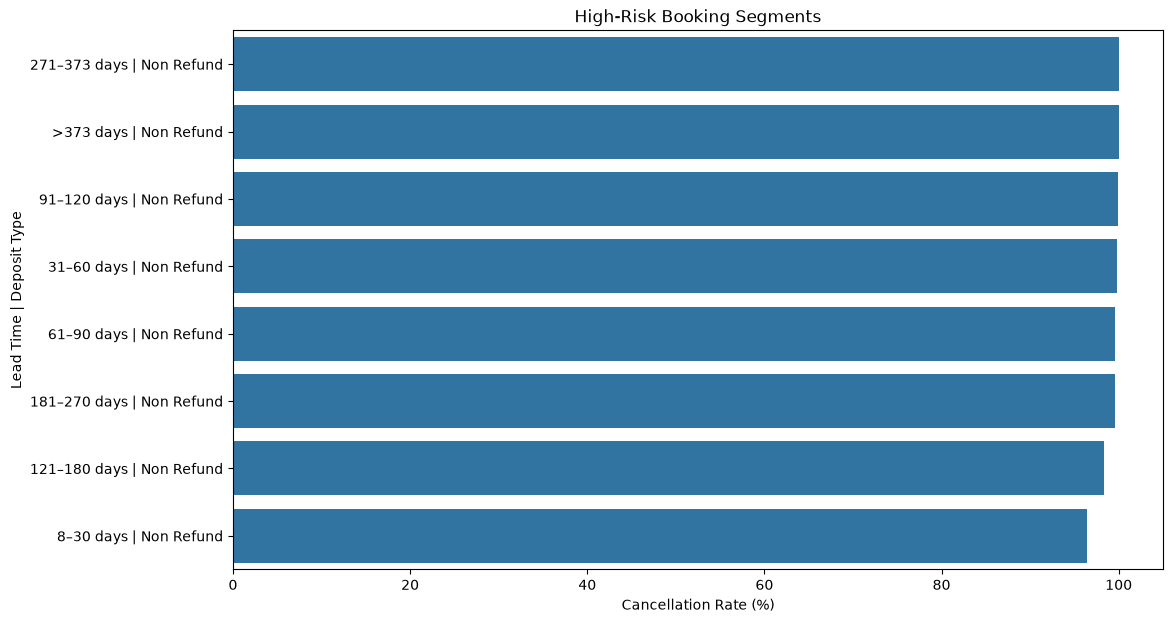

In [67]:
plt.figure(figsize=(12, 7))

plot_data = high_risk.copy()

plot_data['segment'] = (
    plot_data['lead_time_category'].astype(str)
    + ' | '
    + plot_data['deposit_type']
)

sns.barplot(
    data=plot_data,
    x='cancellation_rate',
    y='segment'
)

plt.title('High-Risk Booking Segments')
plt.xlabel('Cancellation Rate (%)')
plt.ylabel('Lead Time | Deposit Type')

plt.show()

In [68]:
special_request_analysis = (
    df.groupby('total_of_special_requests')
      .agg(
          total_bookings=('bookingID', 'count'),
          cancellations=('is_canceled', 'sum')
      )
)

special_request_analysis['cancellation_rate'] = (
    special_request_analysis['cancellations']
    / special_request_analysis['total_bookings']
    * 100
)

special_request_analysis['booking_share'] = (
    special_request_analysis['total_bookings']
    / len(df)
    * 100
)

special_request_analysis

,total_bookings,cancellations,cancellation_rate,booking_share
total_of_special_requests,,,,
0,49035,23357,47.633323,58.870493
1,23200,5077,21.883621,27.853481
2,9041,1999,22.110386,10.854454
3,1743,319,18.301779,2.092613
4,242,23,9.504132,0.290541
5,32,2,6.250000,0.038419


In [69]:
special_request_valid = special_request_analysis[
    special_request_analysis['total_bookings'] >= 100
]

special_request_valid

,total_bookings,cancellations,cancellation_rate,booking_share
total_of_special_requests,,,,
0,49035,23357,47.633323,58.870493
1,23200,5077,21.883621,27.853481
2,9041,1999,22.110386,10.854454
3,1743,319,18.301779,2.092613
4,242,23,9.504132,0.290541


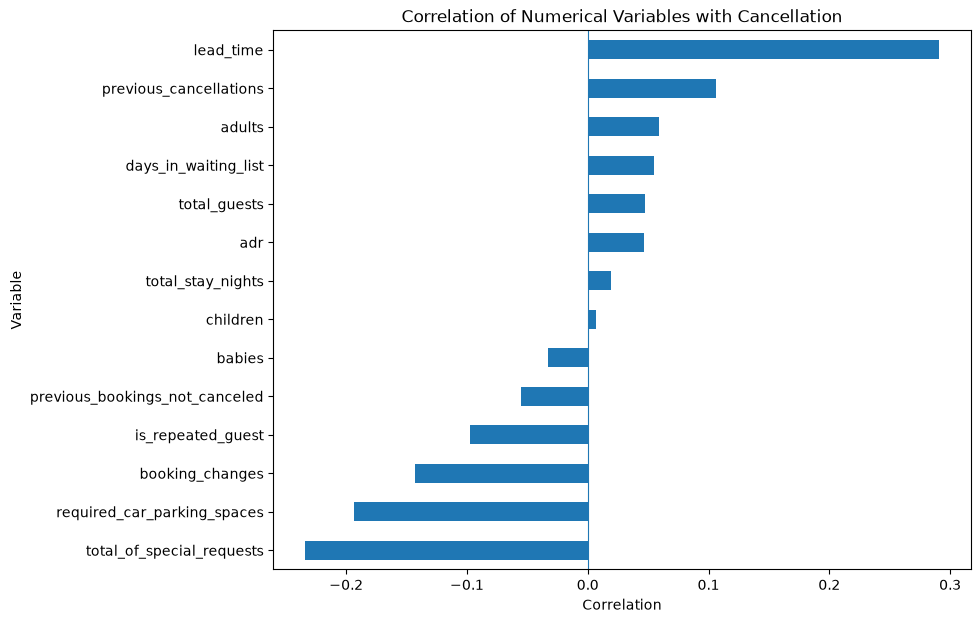

total_of_special_requests        -0.234052
required_car_parking_spaces      -0.193139
booking_changes                  -0.143101
is_repeated_guest                -0.097282
previous_bookings_not_canceled   -0.055482
babies                           -0.033168
children                          0.006436
total_stay_nights                 0.019621
adr                               0.046884
total_guests                      0.047265
days_in_waiting_list              0.054710
adults                            0.059303
previous_cancellations            0.106460
lead_time                         0.290870
Name: is_canceled, dtype: float64

In [70]:
# ============================================================
# Correlation with Cancellation
# ============================================================

correlation_columns = [
    'lead_time',
    'previous_cancellations',
    'previous_bookings_not_canceled',
    'booking_changes',
    'days_in_waiting_list',
    'adr',
    'adults',
    'children',
    'babies',
    'total_guests',
    'total_stay_nights',
    'required_car_parking_spaces',
    'total_of_special_requests',
    'is_repeated_guest'
]

target_corr = (
    df[correlation_columns + ['is_canceled']]
    .corr()['is_canceled']
    .drop('is_canceled')
    .sort_values()
)

plt.figure(figsize=(9, 7))

target_corr.plot(kind='barh')

plt.title('Correlation of Numerical Variables with Cancellation')
plt.xlabel('Correlation')
plt.ylabel('Variable')

plt.axvline(0, linewidth=0.8)

plt.show()
target_corr

In [71]:
stat_columns = [
    'lead_time',
    'adr',
    'total_guests',
    'total_stay_nights',
    'total_of_special_requests',
    'booking_changes'
]

statistics_summary = df[stat_columns].describe().T

statistics_summary['median'] = df[stat_columns].median()
statistics_summary['mode'] = df[stat_columns].mode().iloc[0]
statistics_summary['std'] = df[stat_columns].std()

statistics_summary

,count,mean,std,min,25%,50%,75%,max,median,mode
lead_time,83293.0,103.914230,106.874124,0.0,18.00,69.0,160.0,737.0,69.0,0.0
adr,83293.0,101.724373,48.082552,0.0,69.53,94.5,126.0,508.0,94.5,62.0
total_guests,83293.0,1.966108,0.744195,0.0,2.00,2.0,2.0,55.0,2.0,2.0
total_stay_nights,83293.0,3.434202,2.579232,0.0,2.00,3.0,4.0,69.0,3.0,2.0
total_of_special_requests,83293.0,0.571945,0.793742,0.0,0.00,0.0,1.0,5.0,0.0,0.0
booking_changes,83293.0,0.223068,0.656237,0.0,0.00,0.0,0.0,21.0,0.0,0.0


In [72]:
## Summary of Key Findings

business_insight_summary = pd.DataFrame({
    'Factor': [
        'Lead Time',
        'Deposit Type',
        'Market Segment',
        'Customer Type',
        'Repeat Guest',
        'Special Requests'
    ],
    'Finding': [
        'Cancellation rate increases as lead time becomes longer.',
        'Non Refund bookings show extremely high cancellation rates.',
        'Groups have a relatively high cancellation rate among major segments.',
        'Transient customers show a higher cancellation rate than other major customer types.',
        'Repeat guests have substantially lower cancellation rates than non-repeat guests.',
        'Bookings without special requests have a higher cancellation rate.'
    ],
    'Business_Implication': [
        'Long-lead bookings may require stronger confirmation or cancellation controls.',
        'The non-refundable booking pattern should be investigated and reviewed in booking policy.',
        'Group bookings may require segment-specific booking terms.',
        'Transient customers may require stronger retention or confirmation strategies.',
        'Loyalty strategies may help maintain booking stability.',
        'Customer engagement may be associated with lower cancellation risk.'
    ]
})

business_insight_summary

,Factor,Finding,Business_Implication
0,Lead Time,Cancellation rate increases as lead time becom...,Long-lead bookings may require stronger confir...
1,Deposit Type,Non Refund bookings show extremely high cancel...,The non-refundable booking pattern should be i...
2,Market Segment,Groups have a relatively high cancellation rat...,Group bookings may require segment-specific bo...
3,Customer Type,Transient customers show a higher cancellation...,Transient customers may require stronger reten...
4,Repeat Guest,Repeat guests have substantially lower cancell...,Loyalty strategies may help maintain booking s...
5,Special Requests,Bookings without special requests have a highe...,Customer engagement may be associated with low...


In [73]:
output_file = 'hotel_cancellation_cleaned.csv'

df.to_csv(
    output_file,
    index=False,
    encoding='utf-8-sig'
)

print("Export berhasil!")
print(f"File       : {output_file}")
print(f"Rows       : {df.shape[0]:,}")
print(f"Columns    : {df.shape[1]}")

Export berhasil!
File       : hotel_cancellation_cleaned.csv
Rows       : 83,293
Columns    : 42
